# Exploracion de Steam_data

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Cargamos los datos

In [29]:
df = pd.read_csv("steam_data.csv", sep=";", encoding="utf-8-sig")
df.shape

(62267, 4)

## 2. Forma y estructura

In [30]:
print(df.columns.tolist())
print(df.dtypes)
df.info()

['Game', 'DateTime', 'Players', 'Average Players']
Game                   str
DateTime               str
Players            float64
Average Players    float64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 62267 entries, 0 to 62266
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Game             62267 non-null  str    
 1   DateTime         62267 non-null  str    
 2   Players          60652 non-null  float64
 3   Average Players  14815 non-null  float64
dtypes: float64(2), str(2)
memory usage: 1.9 MB


## 3. Valores null y descripcion

In [31]:
print(df.isna().sum())
df.describe(include="all")

Game                   0
DateTime               0
Players             1615
Average Players    47452
dtype: int64


,Game,DateTime,Players,Average Players
count,62267,62267,6.065200e+04,1.481500e+04
unique,10,8500,NaN,NaN
top,Team Fortress 2,2018-11-16 00:00:00,NaN,NaN
freq,8495,10,NaN,NaN
mean,NaN,NaN,2.365319e+05,1.923764e+05
std,NaN,NaN,3.667164e+05,2.790480e+05
min,NaN,NaN,1.000000e+00,2.615000e+03
25%,NaN,NaN,1.733350e+04,2.274000e+04
50%,NaN,NaN,5.428950e+04,5.750200e+04
75%,NaN,NaN,3.876900e+05,2.765325e+05


## 4. Vistazo a los datos

In [32]:
df.head()

,Game,DateTime,Players,Average Players
0,Among Us,2018-11-16 00:00:00,8.0,NaN
1,Among Us,2018-11-17 00:00:00,17.0,NaN
2,Among Us,2018-11-18 00:00:00,11.0,NaN
3,Among Us,2018-11-19 00:00:00,7.0,NaN
4,Among Us,2018-11-20 00:00:00,8.0,NaN


In [33]:
df.tail()

,Game,DateTime,Players,Average Players
62262,Terraria,2026-10-05 06:30:00,30841.0,NaN
62263,Terraria,2026-10-05 06:40:00,31138.0,NaN
62264,Terraria,2026-10-05 06:50:00,31317.0,NaN
62265,Terraria,2026-10-05 07:00:00,31385.0,38652.0
62266,Terraria,2026-10-05 07:10:00,31542.0,38652.0


In [34]:
print("n_games:", df["Game"].nunique())
print(sorted(df["Game"].unique()))
print("date min:", df["DateTime"].min())
print("date max:", df["DateTime"].max())

n_games: 10
['Among Us', 'Counter-Strike 2', 'Dota 2', 'Hollow Knight', 'PUBG', 'Project Zomboid', 'Rust', 'Stardew Valley', 'Team Fortress 2', 'Terraria']
date min: 2007-09-19 00:00:00
date max: 2026-10-05 07:10:00


## 5. Analisis

In [35]:
df["DateTime"] = pd.to_datetime(df["DateTime"])
df["Año"] = df["DateTime"].dt.year
df["Mes"] = df["DateTime"].dt.month
df["Dia"] = df["DateTime"].dt.day
df["Hora"] = df["DateTime"].dt.hour
df.head()

,Game,DateTime,Players,Average Players,Año,Mes,Dia,Hora
0,Among Us,2018-11-16,8.0,NaN,2018,11,16,0
1,Among Us,2018-11-17,17.0,NaN,2018,11,17,0
2,Among Us,2018-11-18,11.0,NaN,2018,11,18,0
3,Among Us,2018-11-19,7.0,NaN,2018,11,19,0
4,Among Us,2018-11-20,8.0,NaN,2018,11,20,0


### ¿Cuales son los meses con mayor y menor cantidad de jugadores?

Mayor promedio: Marzo (263,412 jugadores)
Menor promedio: Septiembre (212,666 jugadores)


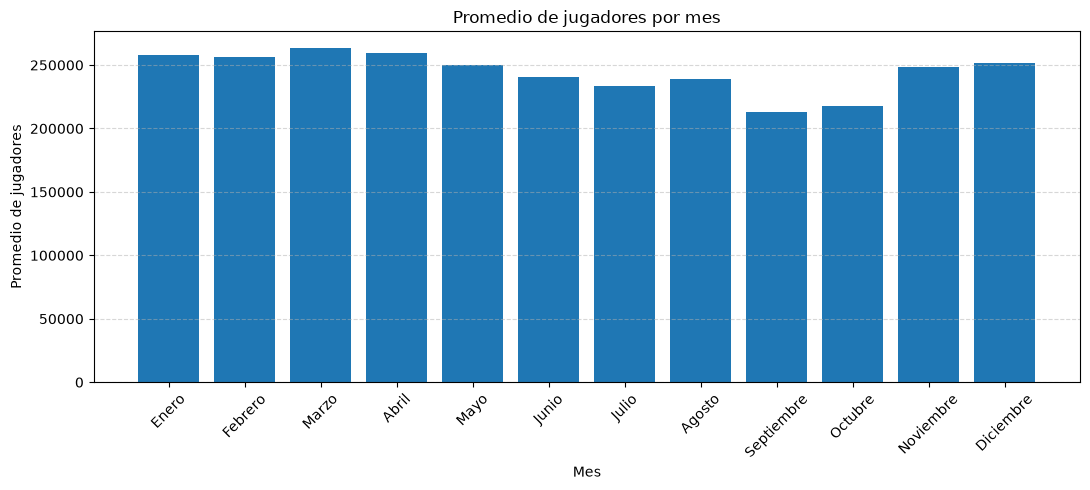

In [36]:
nombres_meses = [
    "Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
    "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"
]

promedio_por_mes = df.groupby("Mes")["Players"].mean().reindex(range(1, 13))
promedio_por_mes = promedio_por_mes.dropna()

mes_maximo = promedio_por_mes.idxmax()
mes_minimo = promedio_por_mes.idxmin()

print(
    f"Mayor promedio: {nombres_meses[mes_maximo - 1]} "
    f"({promedio_por_mes.loc[mes_maximo]:,.0f} jugadores)"
)
print(
    f"Menor promedio: {nombres_meses[mes_minimo - 1]} "
    f"({promedio_por_mes.loc[mes_minimo]:,.0f} jugadores)"
)

plt.figure(figsize=(11, 5))
plt.bar(
    [nombres_meses[mes - 1] for mes in promedio_por_mes.index],
    promedio_por_mes.values
)
plt.title("Promedio de jugadores por mes")
plt.xlabel("Mes")
plt.ylabel("Promedio de jugadores")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### ¿Cual es la hora con mayor y menor cantidad de jugadores?

Mayor promedio: a las 14:00 (310,887 jugadores)
Menor promedio: a las 01:00 (127,761 jugadores)


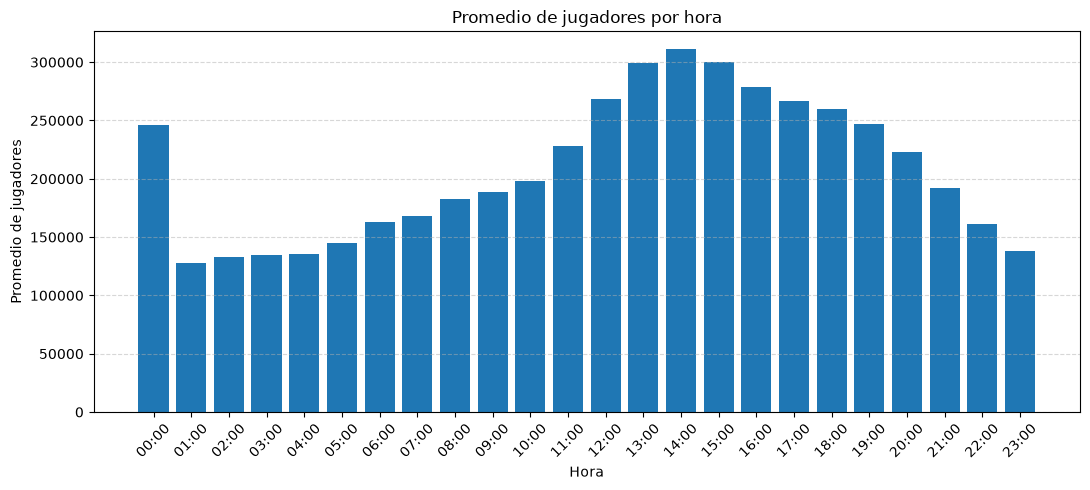

In [37]:
promedio_por_hora = df.groupby("Hora")["Players"].mean().reindex(range(24)).dropna()

hora_maxima = promedio_por_hora.idxmax()
hora_minima = promedio_por_hora.idxmin()

print(
    f"Mayor promedio: a las {hora_maxima:02d}:00 "
    f"({promedio_por_hora.loc[hora_maxima]:,.0f} jugadores)"
)
print(
    f"Menor promedio: a las {hora_minima:02d}:00 "
    f"({promedio_por_hora.loc[hora_minima]:,.0f} jugadores)"
)

plt.figure(figsize=(11, 5))
plt.bar(
    [f"{hora:02d}:00" for hora in promedio_por_hora.index],
    promedio_por_hora.values
)
plt.title("Promedio de jugadores por hora")
plt.xlabel("Hora")
plt.ylabel("Promedio de jugadores")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

- Hay que recalcar que el pico a las 00:00 se debe a que los datos mas antiguos de un mes no estan dividos por hora y solo tienen una entrada para todo el dia, el cual se coloca a las 00:00. Si no tuvieramos en cuenta los datos anteriores al 05/09 el resultado seria el siguiente:

Mayor promedio: a las 14:00 (310,887 jugadores)
Menor promedio: a las 01:00 (127,761 jugadores)


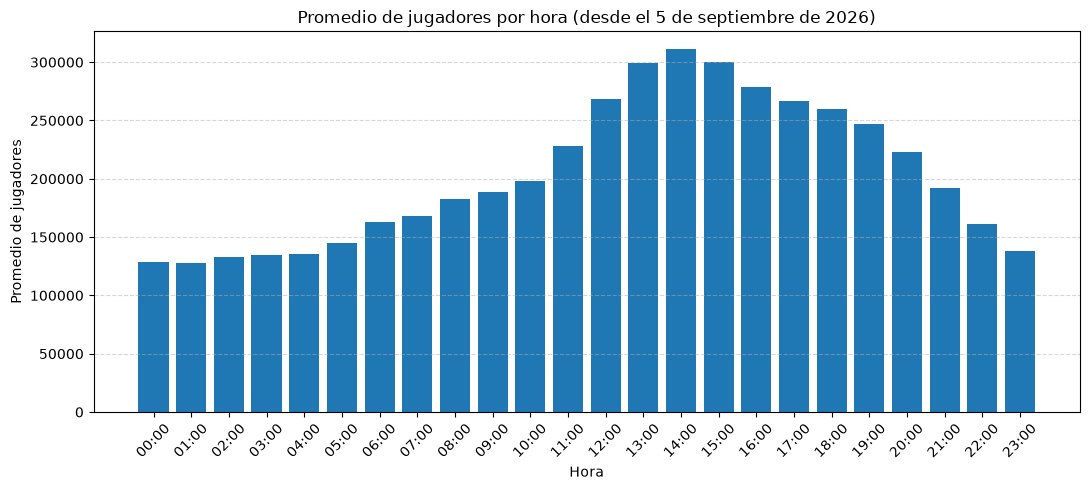

In [38]:
fecha_corte = pd.Timestamp("2026-09-05")
datos_recientes = df[df["DateTime"] >= fecha_corte]

promedio_por_hora = (
    datos_recientes.groupby("Hora")["Players"]
    .mean()
    .reindex(range(24))
    .dropna()
)

hora_maxima = promedio_por_hora.idxmax()
hora_minima = promedio_por_hora.idxmin()

print(
    f"Mayor promedio: a las {hora_maxima:02d}:00 "
    f"({promedio_por_hora.loc[hora_maxima]:,.0f} jugadores)"
)
print(
    f"Menor promedio: a las {hora_minima:02d}:00 "
    f"({promedio_por_hora.loc[hora_minima]:,.0f} jugadores)"
)

plt.figure(figsize=(11, 5))
plt.bar(
    [f"{hora:02d}:00" for hora in promedio_por_hora.index],
    promedio_por_hora.values
)
plt.title("Promedio de jugadores por hora (desde el 5 de septiembre de 2026)")
plt.xlabel("Hora")
plt.ylabel("Promedio de jugadores")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### ¿Que juego ha tenido el pico mas grande de jugadores?

El máximo más alto fue de PUBG: 3,257,248 jugadores.


,Game,Máximo de jugadores
0,PUBG,3257248.0
1,Counter-Strike 2,1862531.0
2,Dota 2,1291328.0
3,Terraria,489886.0
4,Among Us,447476.0
5,Rust,262284.0
6,Team Fortress 2,253997.0
7,Stardew Valley,236614.0
8,Project Zomboid,124995.0
9,Hollow Knight,95655.0


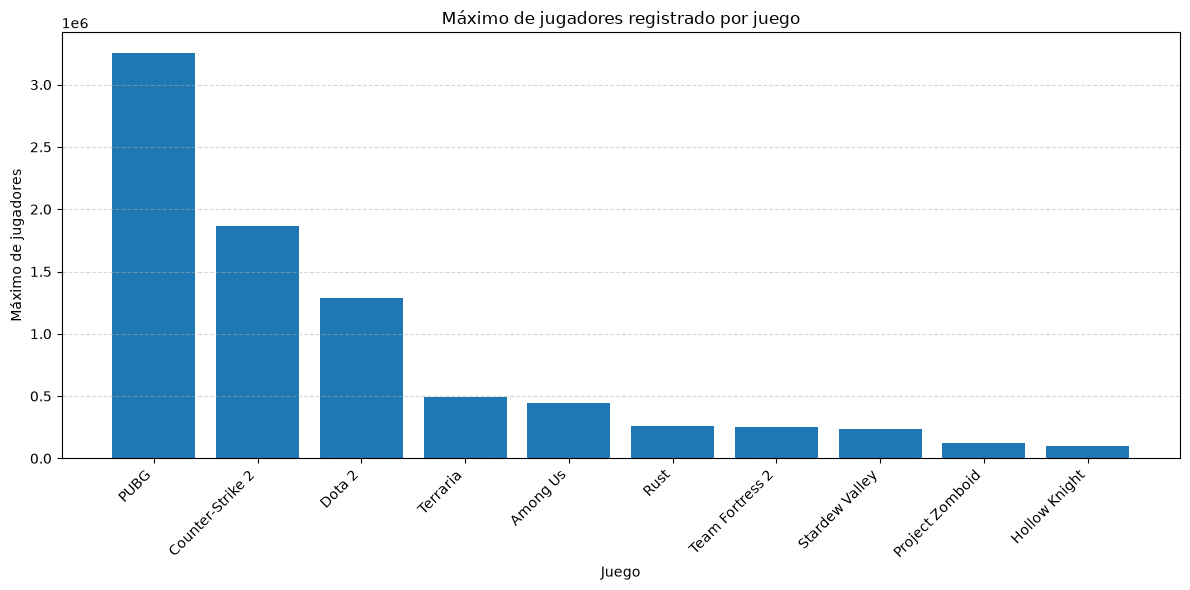

In [39]:
maximos_por_juego = (
    df.groupby("Game")["Players"]
    .max()
    .dropna()
    .sort_values(ascending=False)
)

print(f"El máximo más alto fue de {maximos_por_juego.index[0]}: "
      f"{maximos_por_juego.iloc[0]:,.0f} jugadores.")

display(
    maximos_por_juego.rename("Máximo de jugadores")
    .to_frame()
    .reset_index()
)

plt.figure(figsize=(12, 6))
plt.bar(maximos_por_juego.index, maximos_por_juego.values)
plt.title("Máximo de jugadores registrado por juego")
plt.xlabel("Juego")
plt.ylabel("Máximo de jugadores")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### ¿Que juego ha retenido mejor a sus jugadores?

In [49]:
datos = df.copy()
datos["DateTime"] = pd.to_datetime(datos["DateTime"], errors="coerce")
datos["Players"] = pd.to_numeric(datos["Players"], errors="coerce")
datos = datos.dropna(subset=["Game", "DateTime", "Players"])
datos["Fecha"] = datos["DateTime"].dt.floor("D")

# Promedio de jugadores por día para cada juego
promedios_diarios = (
    datos.groupby(["Game", "Fecha"])["Players"]
    .mean()
    .reset_index()
    .sort_values(["Game", "Fecha"])
)

resultados = []
historiales = {}

for juego, historial in promedios_diarios.groupby("Game"):
    historial = historial.copy()
    fila_pico = historial.loc[historial["Players"].idxmax()]
    ultimo_registro = historial.iloc[-1]
    pico = fila_pico["Players"]

    porcentaje_conservado = (
        round(ultimo_registro["Players"] / pico * 100, 2)
        if pico > 0 else 0
    )

    historiales[juego] = (historial, pico)

    resultados.append({
        "Juego": juego,
        "Fecha del pico": fila_pico["Fecha"],
        "Pico de jugadores": pico,
        "Última fecha": ultimo_registro["Fecha"],
        "Promedio actual de jugadores": ultimo_registro["Players"],
        "% conservado del pico": porcentaje_conservado,
        "% perdido": 100 - porcentaje_conservado
    })

comparacion = (
    pd.DataFrame(resultados)
    .sort_values("% conservado del pico", ascending=False)
    .reset_index(drop=True)
)

def formato_porcentaje(valor):
    return f"{valor:.2f}".rstrip("0").rstrip(".") + " %"

if comparacion.empty:
    print("No hay datos suficientes para comparar los juegos.")
else:
    mejor_juego = comparacion.iloc[0]

    print(
        f"{mejor_juego['Juego']} es el que mejor conserva su base: "
        f"mantiene el {mejor_juego['% conservado del pico']:.2f} % "
        f"de su máximo diario."
    )

    display(comparacion.style.format({
        "Pico de jugadores": "{:,.0f}",
        "Promedio actual de jugadores": "{:,.0f}",
        "% conservado del pico": formato_porcentaje,
        "% perdido": formato_porcentaje,
        "Fecha del pico": lambda fecha: fecha.strftime("%d/%m/%Y"),
        "Última fecha": lambda fecha: fecha.strftime("%d/%m/%Y")
    }))

Project Zomboid es el que mejor conserva su base: mantiene el 39.02 % de su máximo diario.


,Juego,Fecha del pico,Pico de jugadores,Última fecha,Promedio actual de jugadores,% conservado del pico,% perdido
0,Project Zomboid,09/08/2026,"124,995",05/10/2026,"48,773",39.02 %,60.98 %
1,Dota 2,06/03/2016,"1,291,328",05/10/2026,"437,260",33.86 %,66.14 %
2,Counter-Strike 2,12/04/2025,"1,862,531",05/10/2026,"512,665",27.53 %,72.47 %
3,Rust,02/01/2025,"262,284",05/10/2026,"64,043",24.42 %,75.58 %
4,Team Fortress 2,13/07/2023,"253,997",05/10/2026,"57,227",22.53 %,77.47 %
5,Stardew Valley,24/03/2024,"236,614",05/10/2026,"49,182",20.79 %,79.21 %
6,Terraria,16/05/2020,"489,886",05/10/2026,"28,692",5.86 %,94.14 %
7,PUBG,13/01/2018,"3,257,248",05/10/2026,"183,557",5.64 %,94.36 %
8,Hollow Knight,07/09/2025,"95,655",05/10/2026,"5,148",5.38 %,94.62 %
9,Among Us,26/09/2020,"447,476",05/10/2026,"7,475",1.67 %,98.33 %


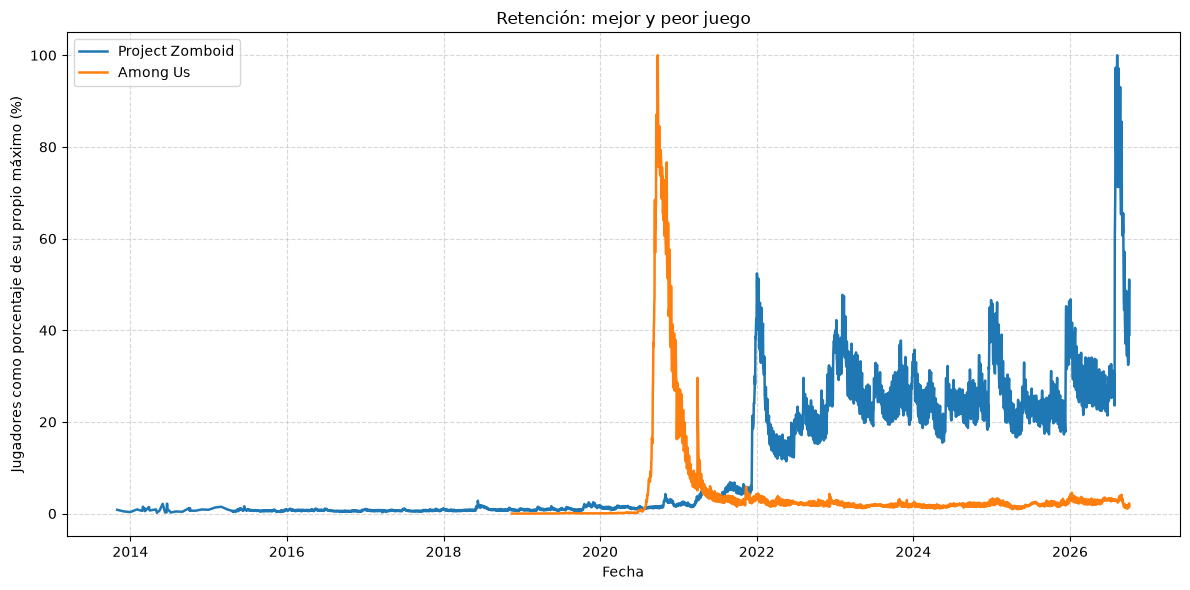

In [47]:
mejor_juego = comparacion.iloc[0]["Juego"]
peor_juego = comparacion.iloc[-1]["Juego"]

plt.figure(figsize=(12, 6))

for juego in [mejor_juego, peor_juego]:
    historial, pico = historiales[juego]
    porcentaje_del_pico = (historial["Players"] / pico * 100).round(2)

    plt.plot(
        historial["Fecha"],
        porcentaje_del_pico,
        label=juego,
        linewidth=1.8
    )

plt.title("Retención: mejor y peor juego")
plt.xlabel("Fecha")
plt.ylabel("Jugadores como porcentaje de su propio máximo (%)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### ¿Cual es el juego mas estable?

El juego más estable es Dota 2, con una variación relativa del 35.71 %.


,Game,Promedio diario,Desviación estándar,Variación relativa (%)
0,Dota 2,"644,359.31","230,129.29",35.71 %
1,Team Fortress 2,"66,126.45","26,156.19",39.55 %
2,Rust,"79,591.28","48,520.33",60.96 %
3,Counter-Strike 2,"755,362.79","470,759.31",62.32 %
4,PUBG,"706,335.26","534,671.37",75.70 %
5,Terraria,"30,641.73","23,866.02",77.89 %
6,Stardew Valley,"43,713.68","38,741.98",88.63 %
7,Hollow Knight,"7,150.23","7,811.00",109.24 %
8,Project Zomboid,"14,551.08","17,507.45",120.32 %
9,Among Us,"19,586.41","51,577.24",263.33 %


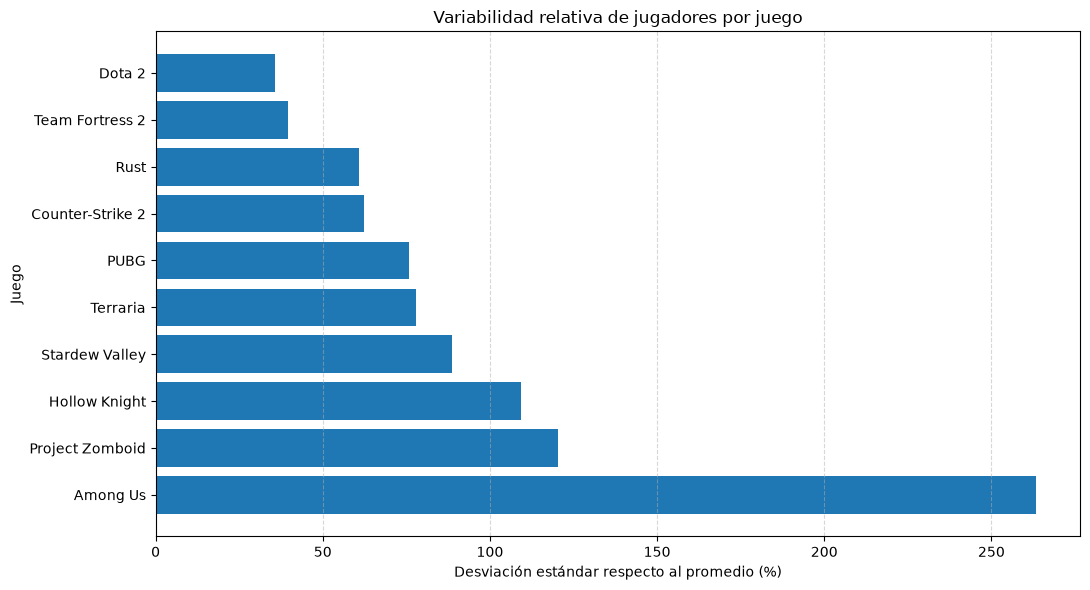

In [53]:
datos = df.copy()
datos["DateTime"] = pd.to_datetime(datos["DateTime"], errors="coerce")
datos["Players"] = pd.to_numeric(datos["Players"], errors="coerce")
datos = datos.dropna(subset=["Game", "DateTime", "Players"])
datos["Fecha"] = datos["DateTime"].dt.floor("D")

# Un promedio por juego y día
promedios_diarios = (
    datos.groupby(["Game", "Fecha"])["Players"]
    .mean()
    .reset_index()
)

# Variación de jugadores a lo largo de los días
estabilidad = (
    promedios_diarios.groupby("Game")["Players"]
    .agg(
        **{
            "Promedio diario": "mean",
            "Desviación estándar": "std"
        }
    )
    .reset_index()
)

# Porcentaje de variación respecto al promedio.
# Cuanto menor sea, más estable es el juego en relación con su tamaño.
estabilidad["Variación relativa (%)"] = (
    estabilidad["Desviación estándar"]
    / estabilidad["Promedio diario"]
    * 100
)

estabilidad = (
    estabilidad.dropna(subset=["Variación relativa (%)"])
    .sort_values("Variación relativa (%)")
    .reset_index(drop=True)
)

if estabilidad.empty:
    print("No hay datos suficientes para comparar la estabilidad.")
else:
    juego_mas_estable = estabilidad.iloc[0]

    print(
        f"El juego más estable es {juego_mas_estable['Game']}, "
        f"con una variación relativa del "
        f"{juego_mas_estable['Variación relativa (%)']:.2f} %."
    )

    display(estabilidad.style.format({
        "Promedio diario": "{:,.2f}",
        "Desviación estándar": "{:,.2f}",
        "Variación relativa (%)": "{:.2f} %"
    }))

    plt.figure(figsize=(11, 6))
    plt.barh(
        estabilidad["Game"],
        estabilidad["Variación relativa (%)"]
    )
    plt.gca().invert_yaxis()
    plt.title("Variabilidad relativa de jugadores por juego")
    plt.xlabel("Desviación estándar respecto al promedio (%)")
    plt.ylabel("Juego")
    plt.grid(axis="x", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

### ¿Cual ha sido el año con mayor numero de jugadores?

El año con mayor promedio diario de jugadores fue 2025, con 3,286,738 jugadores.


,Año,Promedio diario de jugadores
0,2025,"3,286,738"
1,2026,"3,166,298"
2,2024,"3,072,523"
3,2018,"2,945,440"
4,2023,"2,685,585"
5,2017,"2,364,805"
6,2022,"2,350,769"
7,2020,"2,345,798"
8,2021,"2,242,377"
9,2019,"2,235,911"


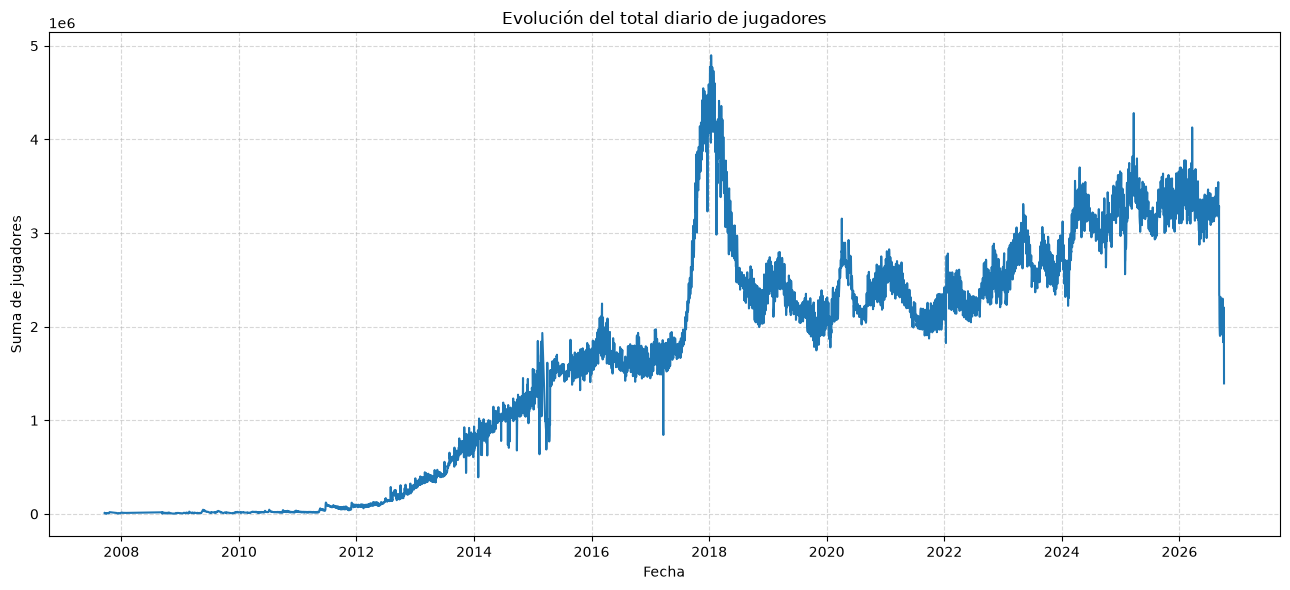

In [55]:
datos_anuales = df.copy()
datos_anuales["DateTime"] = pd.to_datetime(
    datos_anuales["DateTime"], errors="coerce"
)
datos_anuales["Players"] = pd.to_numeric(
    datos_anuales["Players"], errors="coerce"
)
datos_anuales = datos_anuales.dropna(
    subset=["Game", "DateTime", "Players"]
)
datos_anuales["Fecha"] = datos_anuales["DateTime"].dt.floor("D")

# Promedio diario por juego para que la frecuencia de medición no distorsione el resultado
promedio_diario_juego = (
    datos_anuales.groupby(["Game", "Fecha"])["Players"]
    .mean()
    .reset_index()
)

# Suma los promedios de los juegos disponibles en cada fecha
total_diario = (
    promedio_diario_juego.groupby("Fecha")["Players"]
    .sum()
    .reset_index(name="Total de jugadores")
)
total_diario["Año"] = total_diario["Fecha"].dt.year

# Promedio del total diario para cada año
jugadores_por_anio = (
    total_diario.groupby("Año")["Total de jugadores"]
    .mean()
    .sort_values(ascending=False)
    .rename("Promedio diario de jugadores")
    .reset_index()
)

if jugadores_por_anio.empty:
    print("No hay datos suficientes para analizar los años.")
else:
    mejor_anio = jugadores_por_anio.iloc[0]

    print(
        f"El año con mayor promedio diario de jugadores fue "
        f"{int(mejor_anio['Año'])}, con "
        f"{mejor_anio['Promedio diario de jugadores']:,.0f} jugadores."
    )

    display(jugadores_por_anio.style.format({
        "Promedio diario de jugadores": "{:,.0f}"
    }))

    plt.figure(figsize=(13, 6))
plt.plot(
    total_diario["Fecha"],
    total_diario["Total de jugadores"],
    linewidth=1.5
)
plt.title("Evolución del total diario de jugadores")
plt.xlabel("Fecha")
plt.ylabel("Suma de jugadores")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

- Hay que tener en cuenta que el año 2026 todavia no ha finalizado por lo que esos datos estan incompletos

### ¿Son los juegos mas populares mas antiguos o nuevos?

### ¿Que juegos han crecido en jugadores en el ultimo año?

### ¿Hay algun pico o tendencia que se repita a lo largo de varios juegos?

### ¿Afecta el boom de un juego a la popularidad del resto?